# Feature Evaluation - Crypto Perpetuals Funding

This notebook evaluates the complete financial and model-based feature frame on
the two out-of-sample development windows used by downstream model selection.

**Learning Objectives**:
- Assemble 39 financial and five fold-specific temporal features without duplicating rows
- Compute decision-time rank IC with HAC and Benjamini-Hochberg FDR control
- Diagnose cross-sectional identifiability, feature shape, and redundancy
- Record triage diagnostics without filtering the downstream training matrix

**Book Reference**: Chapter 8, Section 8.5 (Feature Evaluation and Triage)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb) and
[`04_model_based_features`](04_model_based_features.ipynb).

In [1]:
"""Evaluate crypto financial and temporal features on canonical validation folds."""

import warnings
from datetime import timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats
from scipy.stats import norm, spearmanr

from utils.cv_splits import load_evaluation_config
from utils.modeling import load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS, add_message_title

warnings.filterwarnings("ignore")

In [2]:
MAX_SYMBOLS = 0

In [3]:
CASE_STUDY_ID = "crypto_perps_funding"
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
EVAL_DIR = CASE_DIR / "evaluation"
EVAL_DIR.mkdir(exist_ok=True)

# The label is read from setup.yaml rather than retyped, so this stage cannot end up
# evaluating a different label than the one the case study declares and the model
# stages train on.
with open(CASE_DIR / "config" / "setup.yaml") as _f:
    setup_config = yaml.safe_load(_f)
PRIMARY_LABEL = setup_config["labels"]["primary"]

JOIN_COLS = ["timestamp", "symbol"]
# Not the label horizon. `fwd_ret_8h` spans exactly one 8-hourly bar, so consecutive
# decision times share no outcome window and overlap contributes no autocorrelation.
# The three lags cover one funding day: the premium and funding features are driven
# by a settlement cycle that repeats every third bar, and that is what the IC series
# carries instead.
HAC_MAXLAGS = 3
MIN_CROSS_SECTION = min(10, MAX_SYMBOLS) if MAX_SYMBOLS else 10
IC_THRESHOLD = 0.005
N_QUANTILES = 5

## 1. Assemble the Exact Validation Frame

`load_modeling_dataset()` is the same assembly path used by notebooks 06-11.
Its placeholder temporal join is schema-only; this notebook replaces those
columns with the matching fold artifact before evaluating each validation slice.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
financial = pl.read_parquet(CASE_DIR / "features" / "financial.parquet")
financial_cols = [name for name in financial.columns if name not in JOIN_COLS]
temporal_cols = mds.temporal_feature_names

assert len(financial_cols) == 39
assert len(temporal_cols) == 5
assert len(mds.feature_names) == 44
assert set(mds.feature_names) == set(financial_cols) | set(temporal_cols)
assert mds.temporal_by_fold is not None

symbols = mds.dataset["symbol"].unique().to_list()
base_frame = mds.dataset.select([*JOIN_COLS, *financial_cols, mds.label_col])
temporal_by_fold = pl.from_pandas(mds.temporal_by_fold).filter(pl.col("symbol").is_in(symbols))

Each row is included once, in the fold where it is out of sample. This prevents
the many-to-many join that results from dropping `fold` before joining the
fold-keyed temporal parquet.

In [5]:
validation_frames = []
for split in mds.splits:
    base = base_frame.filter(
        pl.col("timestamp").is_between(split["val_start"], split["val_end"], closed="both")
    )
    fold_temporal = temporal_by_fold.filter(pl.col("fold") == split["fold"]).select(
        [*JOIN_COLS, *temporal_cols]
    )
    fold_temporal = fold_temporal.with_columns(
        pl.col("timestamp").cast(base.schema["timestamp"])
    ).unique(subset=JOIN_COLS)
    frame = base.join(fold_temporal, on=JOIN_COLS, how="left").with_columns(
        pl.lit(split["fold"]).alias("cv_fold")
    )
    validation_frames.append(frame)

eval_panel = pl.concat(validation_frames).sort(["timestamp", "symbol"])
assert eval_panel.select(JOIN_COLS).is_duplicated().sum() == 0
holdout_start = (
    pl.Series([load_evaluation_config(CASE_STUDY_ID)["holdout_start"]])
    .str.to_datetime()
    .dt.replace_time_zone("UTC")[0]
)
assert eval_panel["timestamp"].max() + timedelta(hours=8) < holdout_start
assert eval_panel.columns == [*JOIN_COLS, *financial_cols, mds.label_col, *temporal_cols, "cv_fold"]

print(f"Validation frame: {len(eval_panel):,} rows, {eval_panel['symbol'].n_unique()} symbols")
print(f"Decision timestamps: {eval_panel['timestamp'].n_unique():,}")
print("Feature contract: 39 financial + 5 fold-specific temporal = 44 [OK]")

Validation frame: 35,160 rows, 19 symbols
Decision timestamps: 2,183
Feature contract: 39 financial + 5 fold-specific temporal = 44 [OK]


## 2. Data Quality and Identifiability

Coverage measures whether a feature is available on the canonical validation
frame. Staleness is diagnostic rather than a failure rule because cost tier and
fold-fitted GARCH parameters are intentionally persistent. Cross-sectional IC
additionally requires variation across symbols at the same timestamp.

In [6]:
quality_rows = []
for feature in mds.feature_names:
    ordered = eval_panel.sort(["symbol", "timestamp"])
    unchanged = ordered.select(
        (pl.col(feature) == pl.col(feature).shift(1).over("symbol")).sum()
    ).item()
    varying_dates = (
        eval_panel.group_by("timestamp")
        .agg(pl.col(feature).drop_nulls().n_unique().alias("n_unique"))
        .filter(pl.col("n_unique") >= 2)
        .height
    )
    quality_rows.append(
        {
            "feature": feature,
            "source": "temporal" if feature in temporal_cols else "financial",
            "coverage": 1 - eval_panel[feature].null_count() / len(eval_panel),
            "staleness": unchanged / max(len(eval_panel) - eval_panel["symbol"].n_unique(), 1),
            "overall_unique": eval_panel[feature].drop_nulls().n_unique(),
            "varying_date_fraction": varying_dates / eval_panel["timestamp"].n_unique(),
        }
    )

quality = pl.DataFrame(quality_rows).with_columns(
    ((pl.col("coverage") >= 0.90) & (pl.col("overall_unique") >= 2)).alias("quality_pass"),
    (pl.col("varying_date_fraction") > 0).alias("cross_sectionally_identifiable"),
)
assert quality.filter(~pl.col("quality_pass")).is_empty()
print(
    quality.group_by("source").agg(
        pl.len().alias("features"),
        pl.col("coverage").min().alias("minimum_coverage"),
        pl.col("cross_sectionally_identifiable").sum().alias("identifiable"),
    )
)

shape: (2, 4)
┌───────────┬──────────┬──────────────────┬──────────────┐
│ source    ┆ features ┆ minimum_coverage ┆ identifiable │
│ ---       ┆ ---      ┆ ---              ┆ ---          │
│ str       ┆ u32      ┆ f64              ┆ u32          │
╞═══════════╪══════════╪══════════════════╪══════════════╡
│ temporal  ┆ 5        ┆ 0.915188         ┆ 3            │
│ financial ┆ 39       ┆ 1.0              ┆ 37           │
└───────────┴──────────┴──────────────────┴──────────────┘


Four common market-state columns are not cross-sectionally identifiable at a
decision timestamp: funding session and funding dispersion from the financial
frame, plus both HMM probabilities. They remain valid conditioning variables in
the 44-column training frame and are not removed by this diagnostic.

## 3. Decision-Time IC and HAC Inference

IC is Spearman correlation within each decision timestamp. The resulting time
series is ordered before Newey-West inference. This notebook never pools rows
across dates or averages per-fold summary statistics.

In [7]:
identifiable = quality.filter(pl.col("cross_sectionally_identifiable"))["feature"].to_list()
partitions = eval_panel.partition_by("timestamp", as_dict=True, maintain_order=True)
ic_results = {}
ic_timeseries = {}

for feature in identifiable:
    observations = []
    for key, group in partitions.items():
        values = group.select(feature, mds.label_col, "cv_fold").drop_nulls()
        if len(values) < MIN_CROSS_SECTION or values[feature].n_unique() < 2:
            continue
        ic, _ = spearmanr(values[feature].to_numpy(), values[mds.label_col].to_numpy())
        if np.isfinite(ic):
            timestamp = key[0] if isinstance(key, tuple) else key
            observations.append(
                {
                    "timestamp": timestamp,
                    "cv_fold": values["cv_fold"][0],
                    "ic": ic,
                    "n_obs": len(values),
                }
            )
    if len(observations) >= 20:
        series = pl.DataFrame(observations).sort("timestamp")
        ic_results[feature] = compute_ic_hac_stats(series["ic"].to_numpy(), maxlags=HAC_MAXLAGS)
        ic_timeseries[feature] = series

print(f"IC evaluated: {len(ic_results)} of {len(mds.feature_names)} features")
print(f"Not cross-sectionally identifiable: {len(mds.feature_names) - len(ic_results)}")

IC evaluated: 40 of 44 features
Not cross-sectionally identifiable: 4


Fold stability uses the same two validation windows. With only two folds the
score can take three values and an interquartile range would be degenerate, so
what it reports is whether the sign agrees in both windows, in one, or in
neither - not a distribution.

In [8]:
fold_stats = {}
for feature, series in ic_timeseries.items():
    per_fold = series.group_by("cv_fold").agg(pl.col("ic").mean()).sort("cv_fold")
    fold_ics = per_fold["ic"].to_list()
    overall_sign = np.sign(ic_results[feature]["mean_ic"])
    fold_stats[feature] = {
        "n_folds": len(fold_ics),
        "sign_consistency": float(np.mean([np.sign(value) == overall_sign for value in fold_ics])),
        "worst_fold_ic": min(fold_ics, key=abs),
        "best_fold_ic": max(fold_ics, key=abs),
    }

stable_count = sum(stats["sign_consistency"] == 1.0 for stats in fold_stats.values())
print(f"Same IC sign in both validation folds: {stable_count}/{len(fold_stats)}")

Same IC sign in both validation folds: 26/40


### The IC series, before it is reduced

Everything below is a scalar summary of one object: the per-decision-time IC
series. Two things are visible only in the series - an IC that comes from a
single episode and is flat around it, and an IC that changes sign between the
two validation windows - so it is drawn first. The band is the HAC interval
around the full-sample mean, computed from the same `compute_ic_hac_stats` call
and therefore at the same `HAC_MAXLAGS` bandwidth as the t-statistics reported
below. `compute_ic_uncertainty` would have drawn it at the Newey-West automatic
lag instead, so the band and the significance test in one notebook would have
rested on different bandwidths. Each validation window is drawn as its own segment:
the folds do not abut, and a line joining the last bar of one to the first bar of
the next would draw a trend across months the notebook never evaluated.

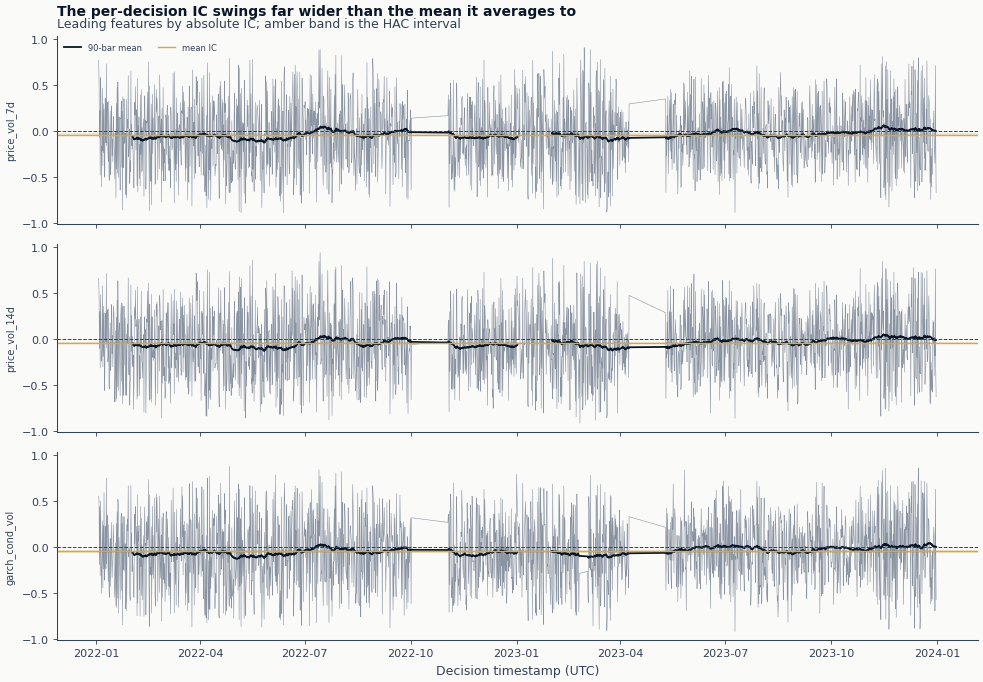

In [9]:
LEADING_FOR_SERIES = 3
ROLLING_BARS = 90
series_features = (
    eval_summary_ordering := sorted(ic_results, key=lambda name: -abs(ic_results[name]["mean_ic"]))
)[:LEADING_FOR_SERIES]

fig, axes = plt.subplots(len(series_features), 1, figsize=(10, 7), sharex=True, sharey=True)
for ax, feature in zip(axes, series_features, strict=True):
    series = ic_timeseries[feature].sort("timestamp")
    stats = ic_results[feature]
    half_width = 1.96 * stats["hac_se"]
    bands = {
        "mean_ic": stats["mean_ic"],
        "ci_hac_lower": stats["mean_ic"] - half_width,
        "ci_hac_upper": stats["mean_ic"] + half_width,
    }
    for index, (_, window) in enumerate(
        sorted(series.group_by("cv_fold"), key=lambda item: item[1]["timestamp"].min())
    ):
        window = window.sort("timestamp")
        stamps = window["timestamp"].to_list()
        ax.plot(stamps, window["ic"].to_list(), color=COLORS["slate"], linewidth=0.4, alpha=0.5)
        ax.plot(
            stamps,
            window["ic"].rolling_mean(ROLLING_BARS, min_samples=ROLLING_BARS).to_list(),
            color=COLORS["blue"],
            linewidth=1.3,
            label=f"{ROLLING_BARS}-bar mean" if index == 0 else "_nolegend_",
        )
    ax.axhline(bands["mean_ic"], color=COLORS["amber"], linewidth=1.0, label="mean IC")
    ax.axhspan(
        bands["ci_hac_lower"], bands["ci_hac_upper"], color=COLORS["amber"], alpha=0.25, lw=0
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7, linestyle="--")
    ax.set_ylabel(feature, fontsize=7)
axes[0].legend(frameon=False, fontsize=6, ncols=2, loc="upper left")
axes[-1].set_xlabel("Decision timestamp (UTC)")
add_message_title(
    axes[0],
    "The per-decision IC swings far wider than the mean it averages to",
    subtitle="Leading features by absolute IC; amber band is the HAC interval",
)
fig.tight_layout()
plt.show()

### Fold-level IC

A pooled mean hides the difference between a feature that works in both
validation windows and one that had a single good year. With two folds there is
no distribution to summarize, so both fold means are drawn per feature and the
reader can see which side of zero each falls on.

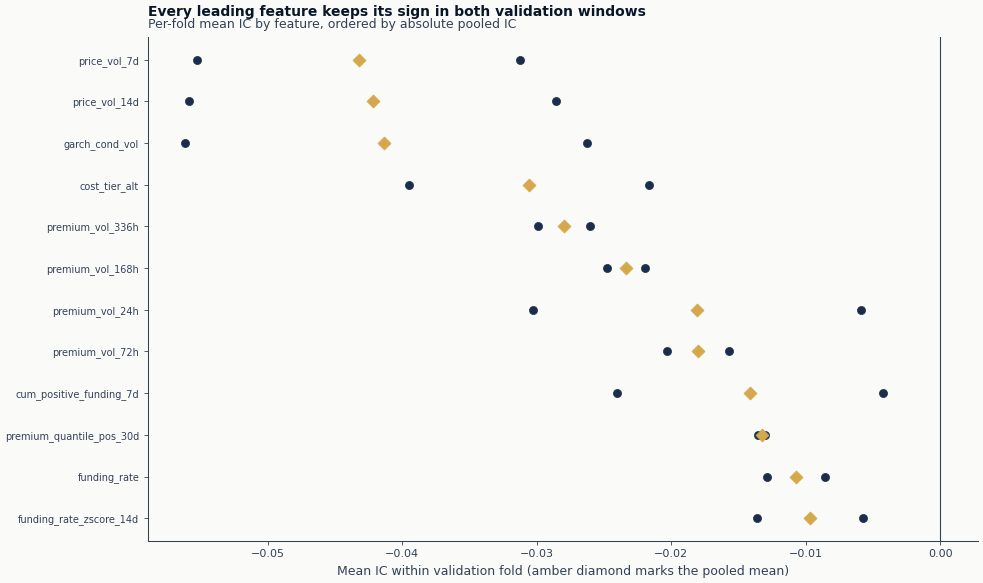

In [10]:
FOLD_FEATURES_SHOWN = 12
fold_features = [name for name in eval_summary_ordering if name in fold_stats][:FOLD_FEATURES_SHOWN]
fig, ax = plt.subplots(figsize=(10, 6))
for row, feature in enumerate(reversed(fold_features)):
    per_fold = (
        ic_timeseries[feature].group_by("cv_fold").agg(pl.col("ic").mean()).sort("cv_fold")["ic"]
    ).to_list()
    ax.scatter(per_fold, [row] * len(per_fold), color=COLORS["slate"], s=34, zorder=3)
    ax.scatter(
        [ic_results[feature]["mean_ic"]],
        [row],
        color=COLORS["amber"],
        marker="D",
        s=44,
        zorder=4,
    )
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_yticks(range(len(fold_features)))
ax.set_yticklabels(list(reversed(fold_features)), fontsize=7)
ax.set_xlabel("Mean IC within validation fold (amber diamond marks the pooled mean)")
add_message_title(
    ax,
    "Every leading feature keeps its sign in both validation windows",
    subtitle="Per-fold mean IC by feature, ordered by absolute pooled IC",
)
fig.tight_layout()
plt.show()

## 4. Multiple Testing

Benjamini-Hochberg correction covers every cross-sectionally identifiable
feature. Naive and HAC significance counts use their respective t-statistics;
neither count is inferred from the other's p-values.

In [11]:
feature_names = list(ic_results)
hac_p_values = [ic_results[name]["p_value"] for name in feature_names]
naive_p_values = [2 * norm.sf(abs(ic_results[name]["naive_t_stat"])) for name in feature_names]
fdr_result = benjamini_hochberg_fdr(hac_p_values, alpha=0.05, return_details=True)

eval_summary = pl.DataFrame(
    {
        "feature": feature_names,
        "source": ["temporal" if name in temporal_cols else "financial" for name in feature_names],
        "mean_ic": [ic_results[name]["mean_ic"] for name in feature_names],
        "hac_t": [ic_results[name]["t_stat"] for name in feature_names],
        "hac_p": hac_p_values,
        "naive_t": [ic_results[name]["naive_t_stat"] for name in feature_names],
        "naive_p": naive_p_values,
        "fdr_p": list(fdr_result["adjusted_p_values"]),
        "fdr_sig": list(fdr_result["rejected"]),
    }
).sort(pl.col("mean_ic").abs(), descending=True)

n_naive = sum(value < 0.05 for value in naive_p_values)
n_hac = sum(value < 0.05 for value in hac_p_values)
n_fdr = int(fdr_result["n_rejected"])
print(f"Significant features: naive={n_naive}, HAC={n_hac}, FDR={n_fdr}")

Significant features: naive=10, HAC=10, FDR=8


The ranked chart shows sign and magnitude; color distinguishes features that
survive FDR control without implying that non-significant conditioning features
should be discarded.

Read the sign before the ranking. Every one of the twenty strongest features
carries a **negative** mean rank IC: high premium, high funding and high realized
volatility all precede *lower* forward returns over the next eight hours. That is
the direction the funding-arbitrage hypothesis predicts - a rich premium is paid
by longs and decays - so the sign is the result, not a defect, and a model built
on these features has to be allowed to trade them short. A feature ranked by
`|IC|` hides that, which is why it is stated here rather than left to the axis.

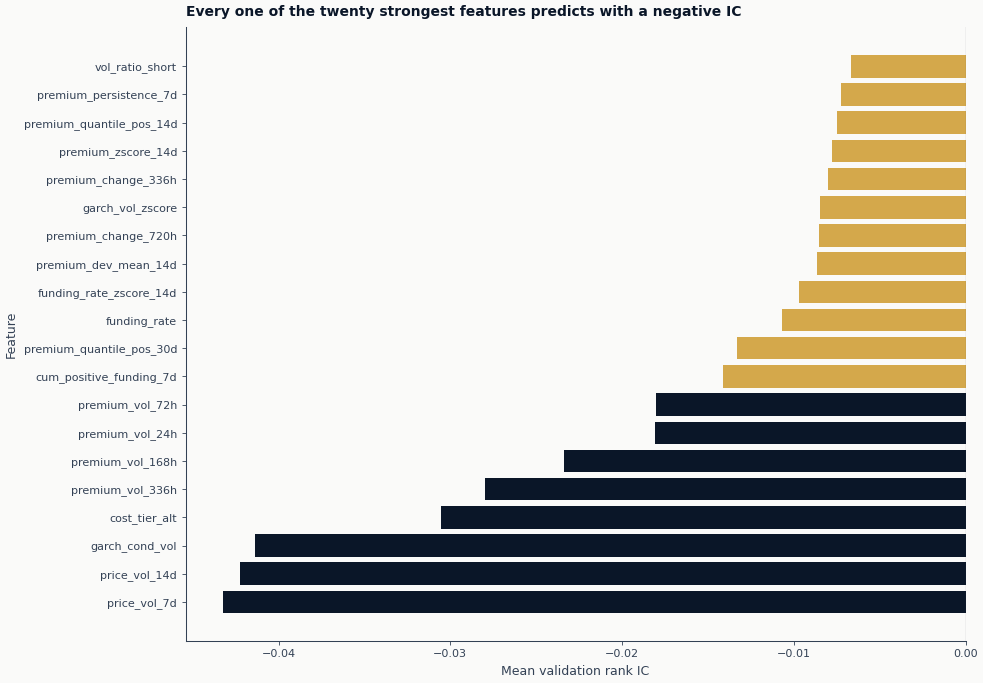

In [12]:
top_ic = eval_summary.head(20).sort("mean_ic")
fig, ax = plt.subplots(figsize=(10, 7))
# Blue against amber, the same pair the HAC scatter below uses for the same
# distinction. COLORS["neutral"] (#334155) beside COLORS["blue"] (#0a1628) is two
# near-black navies: at bar size the encoding is invisible and the reader is told
# about a distinction the chart does not draw.
bar_colors = [COLORS["blue"] if value else COLORS["amber"] for value in top_ic["fdr_sig"]]
ax.barh(top_ic["feature"].to_list(), top_ic["mean_ic"].to_list(), color=bar_colors)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set(xlabel="Mean validation rank IC", ylabel="Feature")
add_message_title(ax, "Every one of the twenty strongest features predicts with a negative IC")
fig.tight_layout()
plt.show()

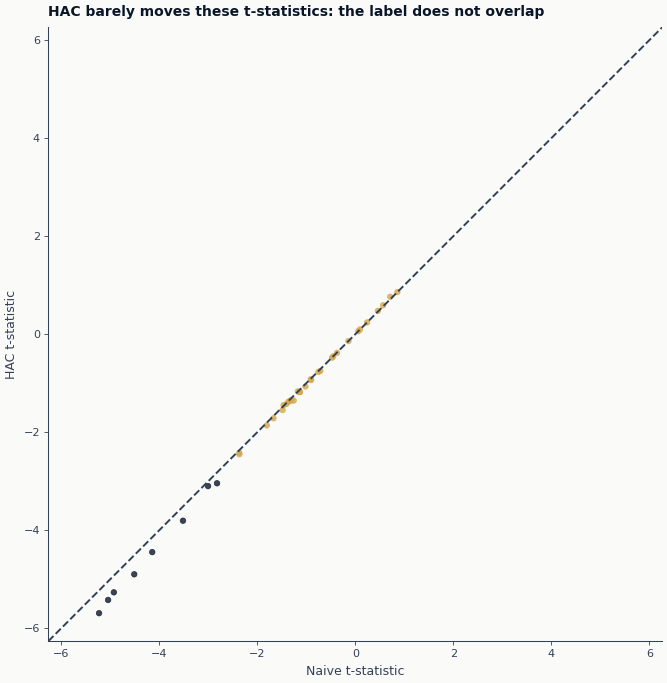

In [13]:
limit = 1.1 * max(eval_summary["naive_t"].abs().max(), eval_summary["hac_t"].abs().max())
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    eval_summary["naive_t"].to_list(),
    eval_summary["hac_t"].to_list(),
    color=[COLORS["blue"] if value else COLORS["amber"] for value in eval_summary["fdr_sig"]],
    alpha=0.8,
)
ax.plot([-limit, limit], [-limit, limit], color=COLORS["neutral"], linestyle="--")
ax.set(
    xlabel="Naive t-statistic", ylabel="HAC t-statistic", xlim=(-limit, limit), ylim=(-limit, limit)
)
ax.set_aspect("equal", adjustable="box")
add_message_title(ax, "HAC barely moves these t-statistics: the label does not overlap")
fig.tight_layout()
plt.show()

## 5. Cross-Sectional Shape

Quantiles are assigned separately at each timestamp before returns are averaged.
This preserves the cross-sectional meaning of IC and avoids letting market-wide
time trends manufacture a pooled quantile relationship.

Two summaries of each bin are drawn. The mean is what a long-short book earns;
the median is where the typical symbol in that bin ends up. Eight-hourly crypto
returns have heavy tails, so the two can point in opposite directions: a handful
of very large moves shift a mean and cannot shift a median. Where they disagree,
the rank IC above sides with the median - not as a theorem, but because both are
insensitive to how far the extreme returns reach, and it is that tail the mean is
reading. `monotonicity` in the ledger is computed on the means, which is the
convention shared across the nine case studies.

In [14]:
shape_features = eval_summary.filter(pl.col("fdr_sig"))["feature"].to_list()[:6]
if not shape_features:
    shape_features = eval_summary.head(6)["feature"].to_list()

quantile_profiles = {}
monotonicity = {}
for feature in shape_features:
    valid = eval_panel.select("timestamp", feature, mds.label_col).drop_nulls()
    ranked = valid.with_columns(
        (
            (pl.col(feature).rank(method="ordinal").over("timestamp") - 1)
            * N_QUANTILES
            / pl.len().over("timestamp")
        )
        .floor()
        .clip(0, N_QUANTILES - 1)
        .cast(pl.Int8)
        .alias("quantile")
    )
    profile = (
        ranked.group_by("quantile")
        .agg(
            pl.col(mds.label_col).mean().alias("mean"),
            pl.col(mds.label_col).median().alias("median"),
        )
        .sort("quantile")
    )
    means = profile["mean"].to_list()
    quantile_profiles[feature] = {"mean": means, "median": profile["median"].to_list()}
    monotonicity[feature] = float(spearmanr(range(len(means)), means).statistic)

print(
    f"Strongly monotone profiles: {sum(abs(value) >= 0.8 for value in monotonicity.values())}/{len(monotonicity)}"
)

Strongly monotone profiles: 2/6


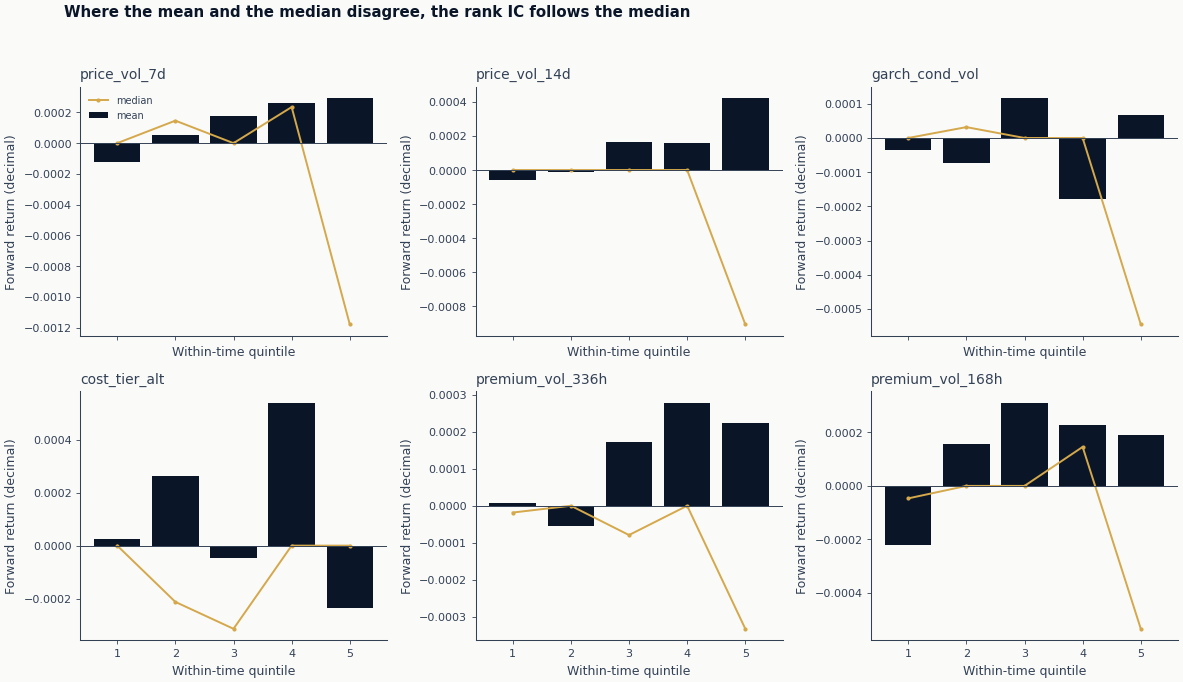

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
for ax, feature in zip(axes.flat, shape_features, strict=False):
    profile = quantile_profiles[feature]
    bins = range(1, len(profile["mean"]) + 1)
    ax.bar(bins, profile["mean"], color=COLORS["blue"], label="mean")
    ax.plot(
        bins, profile["median"], color=COLORS["amber"], marker="o", markersize=3, label="median"
    )
    ax.axhline(0, color=COLORS["neutral"], linewidth=0.7)
    ax.set_title(feature)
    ax.set_xlabel("Within-time quintile")
    ax.set_ylabel("Forward return (decimal)")
axes.flat[0].legend(frameon=False, fontsize=7)
for ax in axes.flat[len(shape_features) :]:
    ax.set_visible(False)
fig.suptitle(
    "Where the mean and the median disagree, the rank IC follows the median",
    x=0.06,
    ha="left",
    color=COLORS["blue"],
    fontweight="semibold",
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()

## 6. Redundancy and Feature Families

The family map is one-to-one and matches notebook 03. Temporal features form
separate volatility and regime families.

In [16]:
financial_families = {
    "carry_funding": [
        name
        for name in financial_cols
        if name.startswith("premium_zscore_")
        or name.startswith("funding_rate")
        or name
        in {"premium_level", "premium_rank", "cum_positive_funding_7d", "funding_half_life_14d"}
    ],
    "mean_reversion": [
        name
        for name in financial_cols
        if any(key in name for key in ["dev_mean", "quantile_pos", "persistence"])
    ],
    "momentum": [
        name
        for name in financial_cols
        if name.startswith("premium_change_") or name.startswith("premium_accel_")
    ],
    "volatility": [
        name
        for name in financial_cols
        if name.startswith(("premium_vol_", "price_vol_", "vol_ratio_"))
    ],
    "cross_sectional": [
        name
        for name in financial_cols
        if name in {"premium_vs_median", "premium_xs_zscore", "xs_funding_dispersion"}
    ],
    "regime_calendar": [
        name
        for name in financial_cols
        if name.startswith(("premium_regime_", "premium_rsi_"))
        or name in {"funding_session", "cost_tier_alt"}
    ],
}

Temporal family membership follows the model that produced each column.

In [17]:
families = {
    **financial_families,
    "temporal_volatility": [name for name in temporal_cols if name.startswith("garch_")],
    "temporal_regime": [name for name in temporal_cols if name.startswith("hmm_")],
}
memberships = {
    name: [family for family, columns in families.items() if name in columns]
    for name in mds.feature_names
}
assert all(len(value) == 1 for value in memberships.values())
feature_family = {name: value[0] for name, value in memberships.items()}

In [18]:
sample_dates = (
    eval_panel["timestamp"]
    .unique()
    .sort()
    .gather_every(max(1, eval_panel["timestamp"].n_unique() // 200))
)
correlation_sample = eval_panel.filter(pl.col("timestamp").is_in(sample_dates))
high_corr_pairs = []
for left_idx, left in enumerate(identifiable):
    for right in identifiable[left_idx + 1 :]:
        pair = correlation_sample.select(left, right).drop_nulls()
        if len(pair) < 20:
            continue
        correlation = float(spearmanr(pair[left].to_numpy(), pair[right].to_numpy()).statistic)
        if np.isfinite(correlation) and abs(correlation) > 0.7:
            high_corr_pairs.append((left, right, correlation))

high_corr_pairs.sort(key=lambda item: abs(item[2]), reverse=True)
print(f"Feature pairs with |rho| > 0.7: {len(high_corr_pairs)}")

Feature pairs with |rho| > 0.7: 58


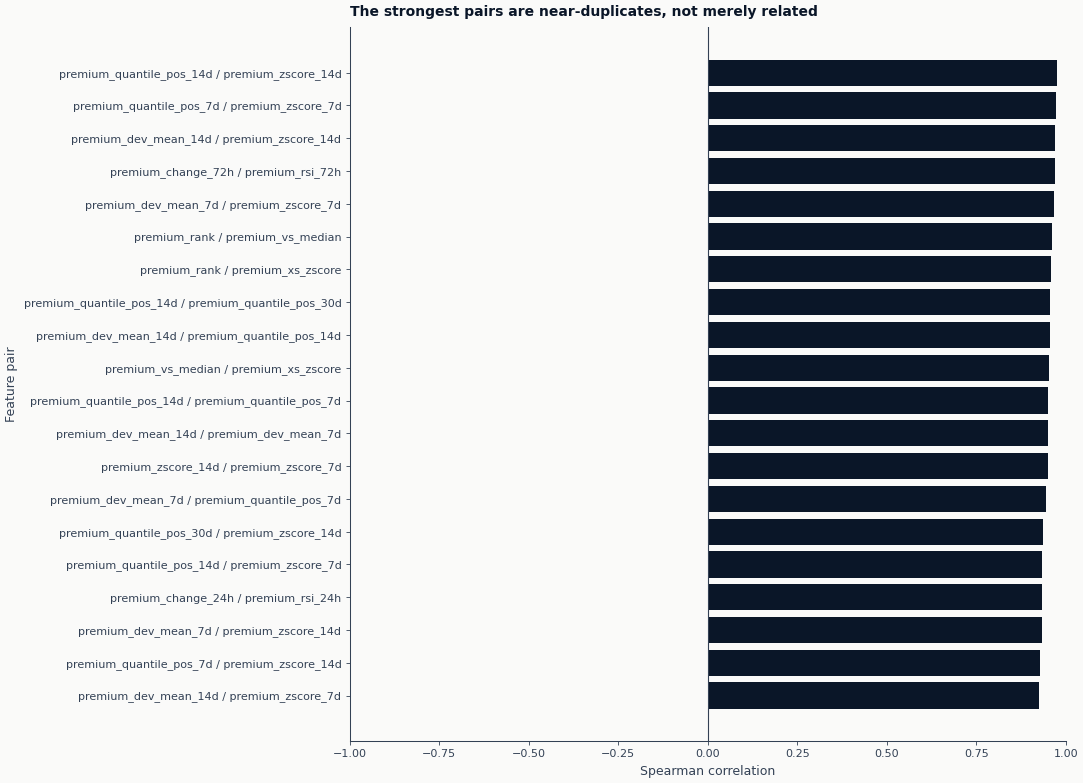

In [19]:
pair_plot = high_corr_pairs[:20][::-1]
pair_labels = [f"{left} / {right}" for left, right, _ in pair_plot]
pair_values = [value for _, _, value in pair_plot]
fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(
    pair_labels,
    pair_values,
    color=[COLORS["blue"] if value >= 0 else COLORS["amber"] for value in pair_values],
)
ax.axvline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set(xlabel="Spearman correlation", ylabel="Feature pair", xlim=(-1, 1))
add_message_title(ax, "The strongest pairs are near-duplicates, not merely related")
fig.tight_layout()
plt.show()

## 7. Triage Ledger

`PROCEED` means the feature has useful univariate validation evidence. `REVISE`
means it remains a plausible conditioning or interaction variable. `STOP` is
reserved for an upstream quality failure. These labels are diagnostic only:
downstream notebooks continue to train the declared 44-feature matrix, avoiding
a second layer of selection on the same validation windows.

In [20]:
def assign_triage(feature: str, quality_row: dict, result: dict | None) -> tuple[str, str]:
    """Apply diagnostic triage without changing the model input contract."""
    if not quality_row["quality_pass"]:
        return "STOP", "quality_failure"
    if result is None:
        return "REVISE", "conditioning_not_cross_sectional"
    is_fdr = bool(fdr_lookup[feature]["fdr_sig"])
    stable = fold_stats[feature]["sign_consistency"] == 1.0
    above_threshold = abs(result["mean_ic"]) >= IC_THRESHOLD
    if is_fdr:
        return "PROCEED", "fdr_significant"
    if stable and above_threshold:
        return "PROCEED", "stable_above_threshold"
    return "REVISE", "weak_univariate"

The ledger retains the evidence needed to reproduce each label.

In [21]:
fdr_lookup = {row["feature"]: row for row in eval_summary.to_dicts()}
ledger_rows = []
for feature in mds.feature_names:
    quality_row = quality.filter(pl.col("feature") == feature).row(0, named=True)
    result = ic_results.get(feature)
    decision, note = assign_triage(feature, quality_row, result)
    ledger_rows.append(
        {
            "feature": feature,
            "family": feature_family[feature],
            "source": quality_row["source"],
            "mean_ic": None if result is None else result["mean_ic"],
            "hac_t": None if result is None else result["t_stat"],
            "fdr_p": None if result is None else fdr_lookup[feature]["fdr_p"],
            "sign_consistency": None if result is None else fold_stats[feature]["sign_consistency"],
            "monotonicity": monotonicity.get(feature),
            "coverage": quality_row["coverage"],
            "staleness": quality_row["staleness"],
            "decision": decision,
            "note": note,
        }
    )

triage_ledger = pl.DataFrame(ledger_rows)
triage_ledger.write_parquet(EVAL_DIR / "triage_ledger.parquet")
print(triage_ledger.group_by("decision").len().sort("decision"))

shape: (2, 2)
┌──────────┬─────┐
│ decision ┆ len │
│ ---      ┆ --- │
│ str      ┆ u32 │
╞══════════╪═════╡
│ PROCEED  ┆ 24  │
│ REVISE   ┆ 20  │
└──────────┴─────┘


In [22]:
ic_ts_all = pl.concat(
    [
        series.with_columns(pl.lit(feature).alias("feature"))
        for feature, series in ic_timeseries.items()
    ]
)
ic_ts_all.write_parquet(EVAL_DIR / "ic_timeseries.parquet")
print(f"Saved triage ledger: {len(triage_ledger)} features")
print(f"Saved IC series: {len(ic_ts_all):,} feature-timestamps")

Saved triage ledger: 44 features
Saved IC series: 79,619 feature-timestamps


## Key Takeaways

1. The evaluation frame contains each validation key once and preserves the
   current 39-plus-five feature contract; `fold` is metadata, never a feature.
2. IC is computed within each decision-time cross-section and HAC inference uses
   the ordered validation IC series from the canonical purged folds.
3. Market-level state variables remain in the training frame even though they
   cannot have cross-sectional IC at a single timestamp.
4. Triage records univariate evidence but does not filter the 44 model inputs,
   preventing validation-driven feature selection from being reused downstream.

**Next**: `06_linear` establishes regularized linear baselines on this fixed
modeling contract.